In [2]:
from Bio import SeqIO
import sys
import torch
from torch.nn.utils.rnn import pad_sequence
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

ModuleNotFoundError: No module named 'Bio'

In [42]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
device

device(type='cuda')

In [43]:
for record in SeqIO.parse("proteins.fasta", "fasta"):
    print(record.id)
    print(record.seq)
    print(len(record.seq))
    print()

sp|P03069|GCN4_YEAST
MSEYQPSLFALNPMGFSPLDGSKSTNENVSASTSTAKPMVGQLIFDKFIKTEEDPIIKQDTPSNLDFDFALPQTATAPDAKTVLPIPELDDAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADKAIESTEEVSLVPSNLEVSTTSFLPTPVLEDAKLTQTRKVKKPNSVVKKSHHVGKDDESRLDHLGVVAYNRKQRSIPLSPIVPESSDPAALKRARNTEAARRSRARKLQRMKQLEDKVEELLSKNYHLENEVARLKKLVGER
281

sp|P05317|RLA0_YEAST
MGGIREKKAEYFAKLREYLEEYKSLFVVGVDNVSSQQMHEVRKELRGRAVVLMGKNTMVRRAIRGFLSDLPDFEKLLPFVKGNVGFVFTNEPLTEIKNVIVSNRVAAPARAGAVAPEDIWVRAVNTGMEPGKTSFFQALGVPTKIARGTIEIVSDVKVVDAGNKVGQSEASLLNLLNISPFTFGLTVVQVYDNGQVFPSSILDITDEELVSHFVSAVSTIASISLAIGYPTLPSVGHTLINNYKDLLAVAIAASYHYPEIEDLVDRIENPEKYAAAAPAATSAASGDAAPAEEAAAEEEEESDDDMGFGLFD
312

sp|P05737|RL7A_YEAST
MAAEKILTPESQLKKSKAQQKTAEQVAAERAARKAANKEKRAIILERNAAYQKEYETAERNIIQAKRDAKAAGSYYVEAQHKLVFVVRIKGINKIPPKPRKVLQLLRLTRINSGTFVKVTKATLELLKLIEPYVAYGYPSYSTIRQLVYKRGFGKINKQRVPLSDNAIIEANLGKYGILSIDDLIHEIITVGPHFKQANNFLWPFKLSNPSGGWGVPRKFKHFIQGGSFGNREEFINKLVKSMN
244

sp|P05748|RL15A_YEAST
MGAYKYLEELQRKKQSDVLRFLQRVRVWEYRQKNVIHRAARPTRPDKARRLGYKAKQGFV

In [44]:
sequences = []

for record in SeqIO.parse("proteins.fasta", "fasta"):
    sequences.append(str(record.seq))

print(len(sequences))
print(sequences[0])

126
MSEYQPSLFALNPMGFSPLDGSKSTNENVSASTSTAKPMVGQLIFDKFIKTEEDPIIKQDTPSNLDFDFALPQTATAPDAKTVLPIPELDDAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADKAIESTEEVSLVPSNLEVSTTSFLPTPVLEDAKLTQTRKVKKPNSVVKKSHHVGKDDESRLDHLGVVAYNRKQRSIPLSPIVPESSDPAALKRARNTEAARRSRARKLQRMKQLEDKVEELLSKNYHLENEVARLKKLVGER


In [45]:
data = []

for record in SeqIO.parse("proteins.fasta", "fasta"):
    data.append({
        "id":record.id,
        "sequence":str(record.seq)
    })

print(data[0])

{'id': 'sp|P03069|GCN4_YEAST', 'sequence': 'MSEYQPSLFALNPMGFSPLDGSKSTNENVSASTSTAKPMVGQLIFDKFIKTEEDPIIKQDTPSNLDFDFALPQTATAPDAKTVLPIPELDDAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADKAIESTEEVSLVPSNLEVSTTSFLPTPVLEDAKLTQTRKVKKPNSVVKKSHHVGKDDESRLDHLGVVAYNRKQRSIPLSPIVPESSDPAALKRARNTEAARRSRARKLQRMKQLEDKVEELLSKNYHLENEVARLKKLVGER'}


In [46]:
df = pd.DataFrame(data)
df.head()

,id,sequence
0,sp|P03069|GCN4_YEAST,MSEYQPSLFALNPMGFSPLDGSKSTNENVSASTSTAKPMVGQLIFD...
1,sp|P05317|RLA0_YEAST,MGGIREKKAEYFAKLREYLEEYKSLFVVGVDNVSSQQMHEVRKELR...
2,sp|P05737|RL7A_YEAST,MAAEKILTPESQLKKSKAQQKTAEQVAAERAARKAANKEKRAIILE...
3,sp|P05748|RL15A_YEAST,MGAYKYLEELQRKKQSDVLRFLQRVRVWEYRQKNVIHRAARPTRPD...
4,sp|P05750|RS3_YEAST,MVALISKKRKLVADGVFYAELNEFFTRELAEEGYSGVEVRVTPTKT...


In [47]:
df["length"] = df["sequence"].apply(len)
df["length"].describe()

count    126.000000
mean     292.801587
std       57.776676
min      203.000000
25%      246.250000
50%      288.000000
75%      343.250000
max      396.000000
Name: length, dtype: float64

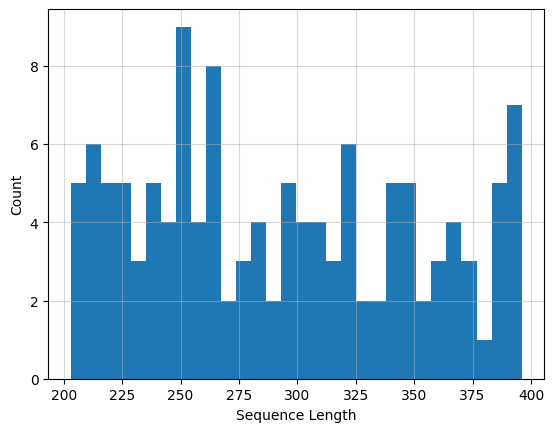

In [48]:
plt.hist(df["length"], bins=30)
plt.xlabel("Sequence Length")
plt.ylabel("Count")
plt.grid(alpha=0.5)
plt.show()

In [49]:
print(df.sequence[0])

MSEYQPSLFALNPMGFSPLDGSKSTNENVSASTSTAKPMVGQLIFDKFIKTEEDPIIKQDTPSNLDFDFALPQTATAPDAKTVLPIPELDDAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADKAIESTEEVSLVPSNLEVSTTSFLPTPVLEDAKLTQTRKVKKPNSVVKKSHHVGKDDESRLDHLGVVAYNRKQRSIPLSPIVPESSDPAALKRARNTEAARRSRARKLQRMKQLEDKVEELLSKNYHLENEVARLKKLVGER


In [50]:
amino_acids = "ACDEFGHIKLMNPQRSTVWY"

aa_to_int = {aa:i for i,aa in enumerate(amino_acids)}

def encode_sequence(seq):
    return [aa_to_int.get(a, 0) for a in seq]

In [51]:
encode_sequence("MSTNTL")

[10, 15, 16, 11, 16, 9]

In [75]:
df["encoded"] = df["sequence"].apply(encode_sequence)

In [53]:
encoded_tensors = [torch.tensor(seq) for seq in df["encoded"]]

X = pad_sequence(encoded_tensors, batch_first=True)

In [54]:
X.shape

torch.Size([126, 396])

In [ ]:


df["label"] = df["id"].apply(label_protein)

y = torch.tensor(df["label"].values)

In [76]:
df["label"]

0      0
1      0
2      0
3      0
4      0
      ..
121    0
122    0
123    0
124    0
125    0
Name: label, Length: 126, dtype: int64

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [57]:
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

In [58]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

## Explicando a elaboracao do modelo:

- Ao definir um modelo define-se uma classe, nesse caso a classe recebe o `Module`  do Pytorch, que dará a possibilidade a ela de virar a classe da rede neural

- Posteriormente, define-se dois módulos: 
  - O `__init__` que serve para definir quais serão as camadas e o `forward` que irá definir qual sequência de treinamento que a rede terá.

- O módulo `__init__` recebe o self como parametro, este que irá definir incoporar a estrutura da rede neural.
    - `__init__` então passa o super chamando ela mesma e aí se dá início a definicão das camadas da rede
- Primeiramente temos:
    - `self.embedding`: é uma funcão do pytorch que permite transformar dados biológicos em vetores de numéricos.
    - `self.conv`: é uma funcao que irá adicionar a primeira camada não linear ao modelo. 
    - `self.pool`: esta funcao é responsável por reduzir a dimensionalidade do modelo.
    - `self.fc`: é uma funcao linear que recebe a saída das camadas ocultas e aplica uma simples transformacao linear sobre os dados, sendo esta a ultima camada dessa rede convolucional

- Já na parte do `forward` desenvolve-se da seguinte maneira:
    - O primeiro passo ao receber os dados é garantir que eles estejam adequados ao funcionamento da rede, portanto, aplica-se a `embedding` juntamente com a `permute` para garantir que o Dataset biológico esteja adequado para as transformacoes matemáticas que serão aplicadas nos passos posteriores.
        - `permute`é uma funcao que apenas troca a ordem dos elementos do Dataset, tratando o array de entrada como uma sequência [0,1,2,4] e posteriormente permitindo o rearranjo: [3,2,0,1]
    
    - No próximo passo são aplicados os neurônios convolucionais da rede, que irão efetuar a operacão convolucional e a aplicacão da funcão ReLU, que irá limpar os elementos que tiveram baixos resultados de fidelidade com relacão a aplicacao dos pesos e viéses dos filtros na etapa convolucional.
    - Já na etapa final, ocorre a reducao da dimensionalidade antes dos resultados dos neurônios serem enviados para a camada linear (final) do modelo. Nota-se que essa reducao da dimensionalidade ocorre com uma funcao `squeeze` atribuida a ela, que além de reduzir a dimensionalidade, remove as dimensões de tamanho 1, tornando o modelo mais limpo.

Dessa forma está montada a classe da rede neural

In [32]:
class ProteinNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.embedding = nn.Embedding(20, 64)

        self.conv = nn.Conv1d(64, 128, 5)

        self.pool = nn.AdaptiveMaxPool1d(1)

        self.fc = nn.Linear(128, 2)

    def forward(self, x):

        x = self.embedding(x)

        x = x.permute(0,2,1)

        x = torch.relu(self.conv(x))

        x = self.pool(x).squeeze()

        return self.fc(x)

In [33]:
model = ProteinNet()

## Os Hiperparâmetros: A Funcão de Perda e o Otimizador

Existem dois hiperparâmetos fundamentais para se desenvolver o treinamento da rede neural, que são:

 - `Criterion` (Loss Function/Funcão de Perda)

 - `Optmizer`

 Em partes: 

 - A funcao de perda basicamente é uma métrica que calcula a distância dos resultados do treinamento em relacão aos testes dados.

 - O `optimizer` representa a funcao que vai atualizar a funcao de perda toda vez que uma `epoch` for rodada 

In [34]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

O `CrossEntropyLoss` pertencente a biblioteca `nn` do pytorch é uma funcao de perda que calcula a distancia dos resultados previstos com relacao aos esperados. Inicialmente, ele transforma os logits da rede em probabilidades por meio da funcao `softmax()` descrita na figura abaixo

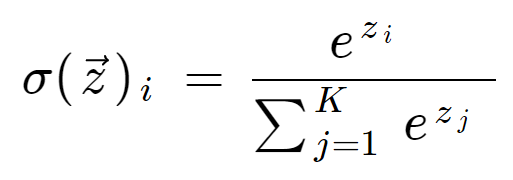

E por último executa o `crossentropy()`, que pode ser observado na figura abaixo, que é basicamente uma relacao entre o resultado previsto pela rede naquela etapa do treinamento e o resultado esperado dado o Dataset de teste

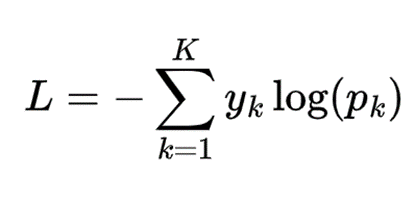


In [35]:
for epoch in range(20):

    model.train()

    total_loss = 0

    for batch_X, batch_y in train_loader:

        optimizer.zero_grad()

        outputs = model(batch_X)

        loss = criterion(outputs, batch_y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print("epoch", epoch, "loss", total_loss)

epoch 0 loss 1.129269463242963
epoch 1 loss 0.0035112612022203393
epoch 2 loss 0.0003378727506060386
epoch 3 loss 0.00010975347504427191
epoch 4 loss 6.096778952269233e-05
epoch 5 loss 4.550796938929125e-05
epoch 6 loss 3.921972711395938e-05
epoch 7 loss 3.544975606928347e-05
epoch 8 loss 3.4436482110322686e-05
epoch 9 loss 3.3222044294234365e-05
epoch 10 loss 3.3378506941517117e-05
epoch 11 loss 3.635870370999328e-05
epoch 12 loss 3.328164939375711e-05
epoch 13 loss 3.3430661460442934e-05
epoch 14 loss 3.3043231724150246e-05
epoch 15 loss 3.245463858547737e-05
epoch 16 loss 3.187349784639082e-05
epoch 17 loss 3.268560431024525e-05
epoch 18 loss 3.173193658767559e-05
epoch 19 loss 3.253659588153823e-05


In [36]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for batch_X, batch_y in test_loader:

        outputs = model(batch_X)

        predicted = torch.argmax(outputs, dim=1)

        correct += (predicted == batch_y).sum().item()

        total += batch_y.size(0)

print("Accuracy:", correct / total)

Accuracy: 1.0


In [37]:
import random

random_seq = X_test[0].unsqueeze(0)

with torch.no_grad():
    pred = model(random_seq)

print(torch.softmax(pred, dim=0))

tensor([9.9999e-01, 5.3728e-06])


In [38]:
torch.save(model.state_dict(), "protein_model.pth")

In [66]:
def predict(sequence):

    encoded = [aa_to_int[a] for a in sequence]

    x = torch.tensor(encoded).unsqueeze(0)

    with torch.no_grad():
        pred = model(x)

    prob = torch.softmax(pred, dim=0)

    return prob

In [67]:
predict("MSTNTLQKLA")

tensor([0.9970, 0.0030])

In [69]:
for seq in sequences:
    prob = predict(seq)
    print(seq, prob)
    print("\n")

MSEYQPSLFALNPMGFSPLDGSKSTNENVSASTSTAKPMVGQLIFDKFIKTEEDPIIKQDTPSNLDFDFALPQTATAPDAKTVLPIPELDDAVVESFFSSSTDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDDVSLADKAIESTEEVSLVPSNLEVSTTSFLPTPVLEDAKLTQTRKVKKPNSVVKKSHHVGKDDESRLDHLGVVAYNRKQRSIPLSPIVPESSDPAALKRARNTEAARRSRARKLQRMKQLEDKVEELLSKNYHLENEVARLKKLVGER tensor([9.9999e-01, 5.6974e-06])


MGGIREKKAEYFAKLREYLEEYKSLFVVGVDNVSSQQMHEVRKELRGRAVVLMGKNTMVRRAIRGFLSDLPDFEKLLPFVKGNVGFVFTNEPLTEIKNVIVSNRVAAPARAGAVAPEDIWVRAVNTGMEPGKTSFFQALGVPTKIARGTIEIVSDVKVVDAGNKVGQSEASLLNLLNISPFTFGLTVVQVYDNGQVFPSSILDITDEELVSHFVSAVSTIASISLAIGYPTLPSVGHTLINNYKDLLAVAIAASYHYPEIEDLVDRIENPEKYAAAAPAATSAASGDAAPAEEAAAEEEEESDDDMGFGLFD tensor([9.9999e-01, 5.1264e-06])


MAAEKILTPESQLKKSKAQQKTAEQVAAERAARKAANKEKRAIILERNAAYQKEYETAERNIIQAKRDAKAAGSYYVEAQHKLVFVVRIKGINKIPPKPRKVLQLLRLTRINSGTFVKVTKATLELLKLIEPYVAYGYPSYSTIRQLVYKRGFGKINKQRVPLSDNAIIEANLGKYGILSIDDLIHEIITVGPHFKQANNFLWPFKLSNPSGGWGVPRKFKHFIQGGSFGNREEFINKLVKSMN tensor([9.9999e-01, 1.1446e-05])


MGAYKYLEELQRKKQSDVLRFLQRVRVWEYRQKNVIHRAARPTRPDKARRLGYKA

In [70]:
preds = []

for seq in sequences:

    p = predict(seq)

    pred_class = torch.argmax(p)

    preds.append(pred_class.item())

print(set(preds))

{0}


In [71]:
print(df["label"].value_counts())

label
0    126
Name: count, dtype: int64


In [72]:
print(df["label"])

0      0
1      0
2      0
3      0
4      0
      ..
121    0
122    0
123    0
124    0
125    0
Name: label, Length: 126, dtype: int64
